In [40]:
from env import (
    make_simglucose_spid_env,
    MultiPatientSimglucoseEnv,
    parse_meal_schedule,
    DEFAULT_MEALS
)

from simglucose.controller.basal_bolus_ctrller import BBController

In [41]:
env = make_simglucose_spid_env(scenario_mode="semi_random_hb", normalize=False)

In [50]:
env.env.env.env.env.env.quest

AttributeError: 'T1DSimEnv' object has no attribute 'quest'

In [19]:
env.cgm_index

0

In [20]:
controller = BBController()

In [36]:
env.quest

AttributeError: 'T1DSimEnv' object has no attribute 'quest'

In [22]:
from BBControllerWrapper import BBPolicy

In [23]:
import pandas as pd
from datetime import timedelta
policy = BBPolicy(env)
obs, info = env.reset()


days = 0

full_history = []

while days <= 1:
    action, _ = policy.predict(obs)

    # Needs sample_time, 
    obs, reward, terminated, truncated, info = env.step(action)

    # print(obs)

    if terminated:
        hist = env.env.env.env.env.env.env.show_history().copy()
        hist.index = hist.index + timedelta(days=1)
        full_history.append(hist)

        obs, info = env.reset()
        days += 1
        break

full_history = pd.concat(full_history)

Observation(CGM=np.float32(146.559))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(147.2832))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(149.32135))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(151.02594))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(152.5808))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(154.10399))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(155.67609))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(157.35574))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(159.18843))
meal : 0.0
ctrller_action(basal=0.01697815740005382, bolus=0.0)
Observation(CGM=np.float32(161.19666))
meal : 0.0
ctrller_action(basal=0.0169

In [24]:
full_history.index

DatetimeIndex(['2018-01-02 00:00:00', '2018-01-02 00:03:00',
               '2018-01-02 00:06:00', '2018-01-02 00:09:00',
               '2018-01-02 00:12:00', '2018-01-02 00:15:00',
               '2018-01-02 00:18:00', '2018-01-02 00:21:00',
               '2018-01-02 00:24:00', '2018-01-02 00:27:00',
               ...
               '2018-01-02 06:21:00', '2018-01-02 06:24:00',
               '2018-01-02 06:27:00', '2018-01-02 06:30:00',
               '2018-01-02 06:33:00', '2018-01-02 06:36:00',
               '2018-01-02 06:39:00', '2018-01-02 06:42:00',
               '2018-01-02 06:45:00', '2018-01-02 06:48:00'],
              dtype='datetime64[ns]', name='Time', length=137, freq=None)

In [25]:
insulin = [float(I) for I in full_history["insulin"]]
full_history["insulin2"] = insulin

C:\Users\sofie\AppData\Local\Temp\ipykernel_41828\247937173.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  insulin = [float(I) for I in full_history["insulin"]]


In [26]:
full_history

,BG,CGM,CHO,insulin,LBGI,HBGI,Risk,insulin2
Time,,,,,,,,
2018-01-02 00:00:00,151.274760,145.816560,0.0,[0.09801666666666667],0.000000,3.058457,3.058457,0.098017
2018-01-02 00:03:00,152.234156,147.283208,0.0,[0.09801666666666667],0.000000,3.190848,3.190848,0.098017
2018-01-02 00:06:00,153.262710,149.321348,0.0,[0.09801666666666667],0.000000,3.334959,3.334959,0.098017
2018-01-02 00:09:00,153.935553,151.025938,0.0,[0.09801666666666667],0.000000,3.430427,3.430427,0.098017
2018-01-02 00:12:00,154.383646,152.580790,0.0,[0.09801666666666667],0.000000,3.494523,3.494523,0.098017
...,...,...,...,...,...,...,...,...
2018-01-02 06:36:00,17.172926,39.000000,0.0,[0.09801666666666667],118.039935,0.000000,118.039935,0.098017
2018-01-02 06:39:00,15.263972,39.000000,0.0,[0.09801666666666667],132.915881,0.000000,132.915881,0.098017
2018-01-02 06:42:00,13.336974,39.000000,0.0,[0.09801666666666667],150.963899,0.000000,150.963899,0.098017


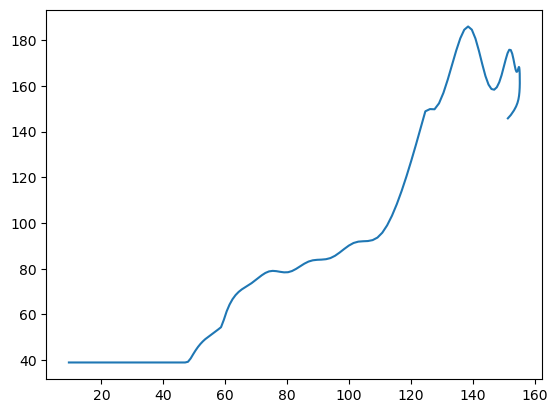

In [27]:
plt.plot(full_history["BG"], full_history["CGM"])

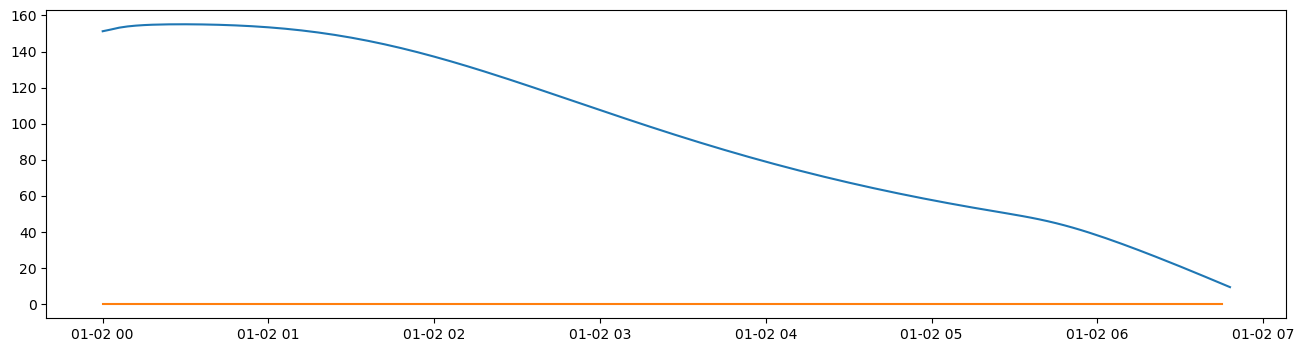

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["BG"])
plt.plot(full_history.index, full_history["CHO"])

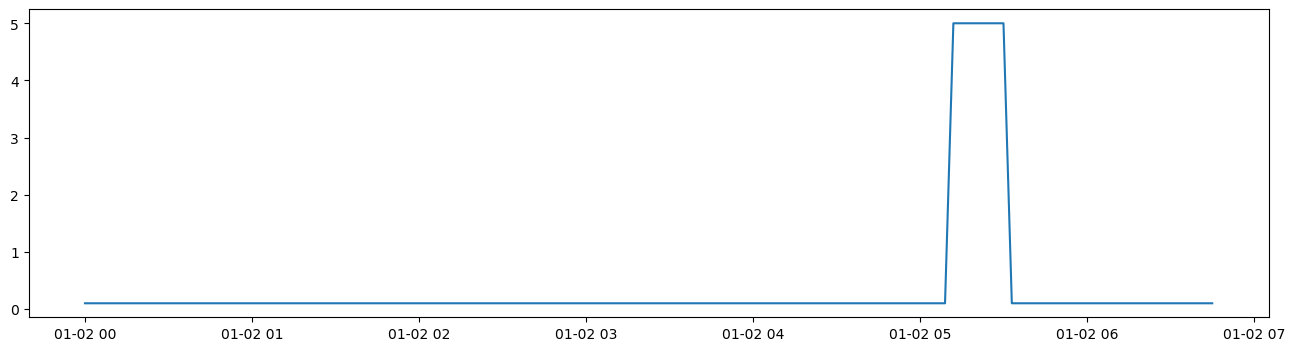

In [29]:
plt.figure(figsize=(16, 4))
plt.plot(full_history.index, full_history["insulin2"])

Observation(CGM=np.float64(157.3231568938086))
Observation(CGM=np.float64(157.310988694269))
Observation(CGM=np.float64(157.08212506758503))
Observation(CGM=np.float64(156.29854142349257))
Observation(CGM=np.float64(154.99163965504385))
Observation(CGM=np.float64(153.08422180470208))
Observation(CGM=np.float64(150.42042871219047))
Observation(CGM=np.float64(146.8704464334352))
Observation(CGM=np.float64(142.4236279302522))
Observation(CGM=np.float64(137.1894648692957))
Observation(CGM=np.float64(131.24244390724897))
Observation(CGM=np.float64(124.48924455010041))
Observation(CGM=np.float64(116.789797110928))
Observation(CGM=np.float64(108.0545541030809))
Observation(CGM=np.float64(98.38460290363167))
Observation(CGM=np.float64(88.18138376241308))
Observation(CGM=np.float64(78.16855520874122))
Observation(CGM=np.float64(69.08179809660821))
Observation(CGM=np.float64(61.59605433082241))
Observation(CGM=np.float64(56.25475900436811))
Observation(CGM=np.float64(53.04436489443367))
Observat

KeyboardInterrupt: 

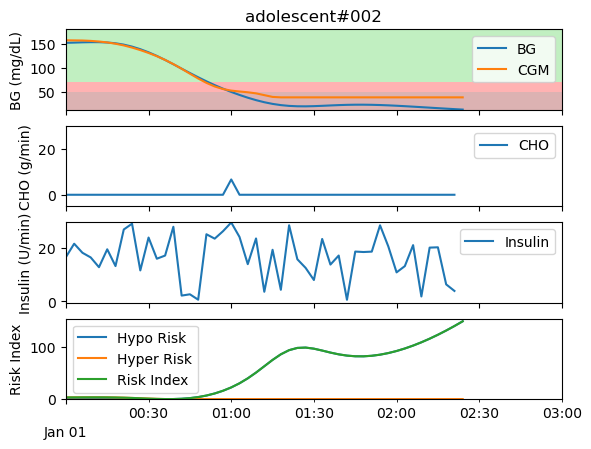

In [36]:
import gym
from gym.envs.registration import register
from simglucose.simulation.scenario import CustomScenario
from datetime import datetime

start_time = datetime(2018, 1, 1, 0, 0, 0)
meal_scenario = CustomScenario(start_time=start_time, scenario=[(1,20)])


# register(
#     id='simglucose-adolescent2-v1',
#     entry_point='simglucose.envs:T1DSimEnv',
#     kwargs={'patient_name': 'adolescent#002',
#             'custom_scenario': meal_scenario}
# )

observation = env.reset()
for t in range(100):
    env.render(mode='human')
    print(observation)
    # Action in the gym environment is a scalar
    # representing the basal insulin, which differs from
    # the regular controller action outside the gym
    # environment (a tuple (basal, bolus)).
    # In the perfect situation, the agent should be able
    # to control the glucose only through basal instead
    # of asking patient to take bolus
    action = env.action_space.sample()
    observation, reward, done, info = env.step(action)
    if done:
        print("Episode finished after {} timesteps".format(t + 1))
        break

env = gym.make('simglucose-adolescent2-v1')

In [ ]:
from simglucose.simulation.env import T1DSimEnv
from simglucose.controller.basal_bolus_ctrller import BBController
from simglucose.controller.pid_ctrller import PIDController

from simglucose.sensor.cgm import CGMSensor
from simglucose.actuator.pump import InsulinPump
from simglucose.patient.t1dpatient import T1DPatient
from simglucose.simulation.scenario_gen import RandomScenario
from simglucose.simulation.scenario import CustomScenario
from simglucose.simulation.sim_engine import SimObj, sim, batch_sim
from datetime import timedelta
from datetime import datetime

# specify start_time as the beginning of today
now = datetime.now()
start_time = datetime.combine(now.date(), datetime.min.time())

# --------- Create Random Scenario --------------
# Specify results saving path
path = './results'

# Create a simulation environment
patient = T1DPatient.withName('adult#001')
sensor = CGMSensor.withName('Dexcom')
pump = InsulinPump.withName('Insulet')
scenario = RandomScenario(start_time=start_time)
env = T1DSimEnv(patient, sensor, pump, scenario)

# Create a controller

controller = PIDController(I=1, D=1)

# Put them together to create a simulation object

patient_list = ['adult#001'] #, 'adult#002', 'adult#003', 'adult#004', 'adult#005', 'adult#006', 'adult#007']


result_list = []
# for p_name in patient_list
for i in range(10):
    patient = T1DPatient.withName('adult#001')
    sensor = CGMSensor.withName('Dexcom')
    pump = InsulinPump.withName('Insulet')
    #controller = BBController()



    scenario = RandomScenario(start_time=start_time)
    env = T1DSimEnv(patient, sensor, pump, scenario)

    s1 = SimObj(env, controller, timedelta(days=10), animate=False, path=path)
    results1 = sim(s1)
    #s1.reset()
    #env.reset()

    result_list.append(results1)
print(results1)

Process ID: 41144
Simulation starts ...
Simulation Completed!
                               BG         CGM  CHO    insulin  LBGI      HBGI  \
Time                                                                            
2026-05-13 00:00:00  1.385600e+02  139.970963  0.0  30.000000   0.0  1.510902   
2026-05-13 00:03:00  1.385600e+02  141.968880  0.0   7.630575   0.0  1.510900   
2026-05-13 00:06:00  1.385585e+02  141.810937  0.0  13.296008   0.0  1.510745   
2026-05-13 00:09:00  1.385436e+02  140.457376  0.0  16.976717   0.0  1.509185   
2026-05-13 00:12:00  1.384794e+02  138.213728  0.0  15.808500   0.0  1.502456   
...                           ...         ...  ...        ...   ...       ...   
2026-05-22 23:48:00 -2.415368e-12   39.000000  0.0   0.000000   0.0  0.000000   
2026-05-22 23:51:00 -2.415368e-12   39.000000  0.0   0.000000   0.0  0.000000   
2026-05-22 23:54:00 -2.415368e-12   39.000000  0.0   0.000000   0.0  0.000000   
2026-05-22 23:57:00 -2.415368e-12   39.000000  

In [70]:
controller.integrated_state

np.float64(-1449207.7779701557)

In [ ]:
env.quest

AttributeError: 'T1DSimEnv' object has no attribute 'quest'

Index(['BG', 'CGM', 'CHO', 'insulin', 'LBGI', 'HBGI', 'Risk'], dtype='object')


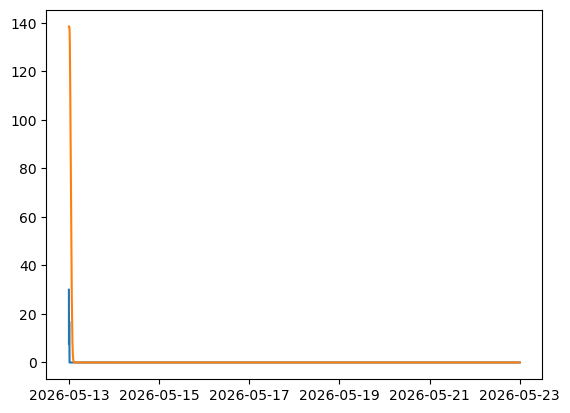

In [66]:
print(results1.columns)
plt.plot(results1["insulin"])
plt.plot(results1["BG"])

<Figure size 1200x600 with 0 Axes>

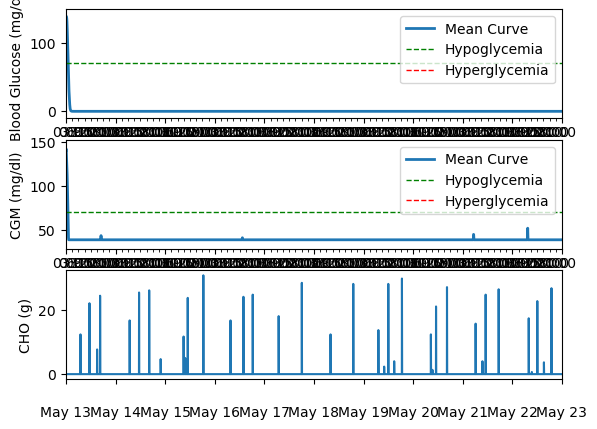

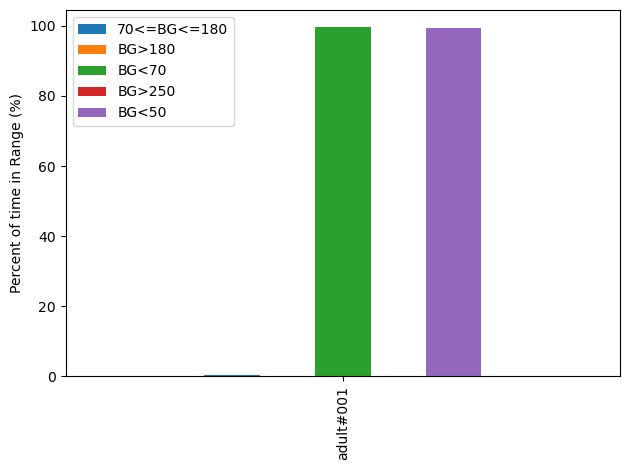

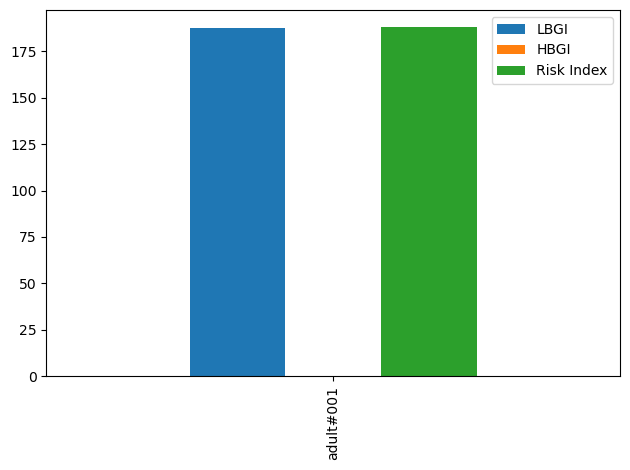

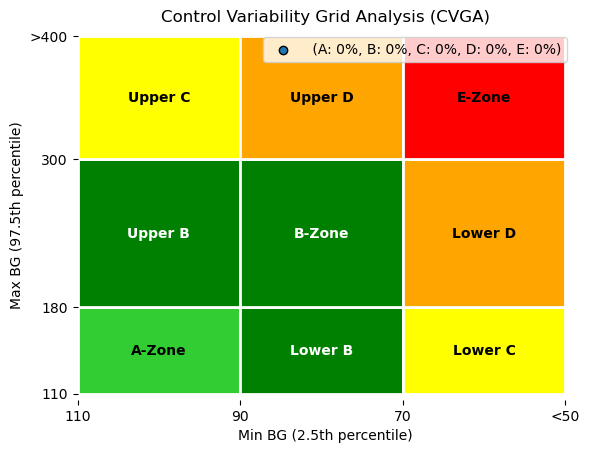

(           70<=BG<=180  BG>180      BG<70  BG>250      BG<50       LBGI  \
 adult#001     0.458238     0.0  99.541762     0.0  99.479275  187.56356   
 
                HBGI  Risk Index  
 adult#001  0.267424  187.830984  ,
                            0          1           2    3    4    5    6    \
 LBGI       adult#001  0.341657  82.264883  480.084139  NaN  NaN  NaN  NaN   
 HBGI       adult#001  0.802272   0.000000    0.000000  NaN  NaN  NaN  NaN   
 Risk Index adult#001  1.143929  82.264883  480.084139  NaN  NaN  NaN  NaN   
 
                       7    8    9    ...  230  231  232  233  234  235  236  \
 LBGI       adult#001  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
 HBGI       adult#001  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
 Risk Index adult#001  NaN  NaN  NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
 
                       237  238  239  
 LBGI       adult#001  NaN  NaN  NaN  
 HBGI       adult#001  NaN  NaN  NaN  
 Risk Index adult#001 

In [68]:
from simglucose.analysis.report import report
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

df = pd.concat(
        result_list,
        keys=patient_list)

plt.figure(figsize=(12, 6))
report(df)